# AMATH 445: Final Project
## Depth Estimation on Colonic footage
### Model: MiDaS - DPT_Hybrid
Prepared by: Darren Lam Kin Teng (20977843)

In [58]:
import os
import glob
import re
import cv2
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import lr_scheduler, Adam
from sklearn.utils import resample
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image

Variables

In [59]:
IMAGE_PATH = "/content/drive/MyDrive/cecum_t1_a/color"
IMAGE_DEPTH_PATH = "/content/drive/MyDrive/cecum_t1_a/depth"
RANDOM_SEED = 123
# BATCH_SIZE = 4
MAX_EPOCHS = 10

MODEL_TYPE = 'DPT_Hybrid' # can either be "DPT_Hybrid" or "MiDaS_Small"
BATCH_SIZE_LIST = [4, 8, 12]
LEARNING_RATE_LIST = [1e-5, 1e-4, 1e-3]
HYPER_PARAMETER_SET = list(itertools.product(BATCH_SIZE_LIST, LEARNING_RATE_LIST))

TRAIN_RATIO = 0.7
VAL_RATIO = (1.0 - TRAIN_RATIO)/2
TEST_RATIO = VAL_RATIO

Helper functions and classes

In [60]:
def resize_predictions(predictions, ground_truths):
  """
  Resizes the model predictions to ground truths size. Result is used for calculating
  loss function.
  """
  resized = torch.nn.functional.interpolate(predictions.unsqueeze(1),
                                            mode='bicubic',
                                            size = ground_truths.shape[-2:],
                                            align_corners=False).squeeze(1)
  return resized

def scale_invariant_loss(prediction, target):
  """
  A scale-invariant loss function specifically for MiDaS.
  """
  mask = target > 0 # filter out all invalid pixels
  prediction = prediction[mask]
  target = target[mask]
  M = mask.sum().float()

  # normalize the pixel values for target and prediction
  # adding a small value to standard deviation to prevent division by 0
  prediction_norm = (prediction - prediction.mean()) / (prediction.std() + 1e-6)
  target_norm = (target - target.mean()) / (target.std() + 1e-6)

  # Loss function
  loss = 1.0 / (2. * M) * torch.sum(torch.abs(prediction_norm - target_norm))
  return loss

def get_image_pairs(img_folder: str, depth_folder: str):
  """
  The function gets a pair of the image and its depth map image and returns a
  list of dictionaries.
  """
  # Pre-emptive checks
  if os.path.exists(img_folder) and os.path.exists(depth_folder):
    img_files   = glob.glob(os.path.join(img_folder, '*.png'))
    depth_files = glob.glob(os.path.join(depth_folder, '*.tiff'))
    img_folder_count   = len(img_files)
    depth_folder_count = len(depth_files)

  else:
    print('One or both files do not exist.')

  if img_folder_count != depth_folder_count:
    print('Mismatch in number of images found in files. {} missing'.format(abs(img_folder_count - depth_folder_count)))

  # get the image pairs
  depth_dict = {}
  for path in depth_files:
    filename = os.path.basename(path)
    _match = re.match(r'^(\d{4})_', filename)
    if _match:
      depth_dict[_match.group(1)] = path

  pairs = list()
  unmatched = list()

  for color_path in sorted(img_files):
    filename = os.path.basename(color_path)
    image_match = re.match(r'^(\d+)_', filename)
    if image_match:
      image_prefix = image_match.group(1).zfill(4)
      if image_prefix in depth_dict:
        pairs.append({
            'color': color_path,
            'depth': depth_dict[image_prefix]
        })
      else:
        unmatched.append(filename)

  if unmatched:
    print('No depth match found for {} color image (s): {}'.format(len(unmatched), unmatched))

  print('Successfully paired {} images'.format(len(pairs)))
  return pairs

def train_val_test_split(pairs: list, random_state = RANDOM_SEED, train_ratio=TRAIN_RATIO,
                         val_ratio = VAL_RATIO, test_ratio=TEST_RATIO):
  """
  Function creates training, validation and test split for image pairs.

  Returns a dictionary for such split.
  """
  train_pairs, temp_pairs = train_test_split(pairs, test_size= test_ratio + val_ratio, random_state = RANDOM_SEED)

  val_pairs, test_pairs = train_test_split(temp_pairs, test_size = 0.5, random_state = RANDOM_SEED)

  splits = {
      'train': train_pairs,
      'val': val_pairs,
      'test': test_pairs
  }

  return splits

In [61]:
class DepthDataset(Dataset):
  """
  Class creates a PyTorch dataset.
  """
  def __init__(self, pairs: list, depth_size = (384, 480), transform=None):
    self.transform = transform
    self.pairs = pairs
    self.depth_size = depth_size

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self, idx):
    pair = self.pairs[idx]
    color_image = np.array(Image.open(pair['color']).convert('RGB'))
    depth_image = Image.open(pair['depth'])
    depth_image = depth_image.resize(
        (self.depth_size[1], self.depth_size[0]), resample=Image.NEAREST
    )

    depth_image = np.array(depth_image)

    # Use MiDaS transformation for the images
    if self.transform:
      color_image = self.transform(color_image).squeeze(0)

    return {
        'color': color_image,
        'depth_gt': torch.tensor(depth_image, dtype=torch.float32)
    }

class EarlyStopping():
  """
  Class performs early stopping on model training and validation.
  """
  def __init__(self, patience=5, min_delta=0.001):
    self.patience = patience
    self.min_delta = min_delta
    self.stop = False
    self.best_loss = float('inf')
    self.counter = 0

  def __call__(self, val_loss):
    if val_loss < self.best_loss:
      self.counter  = 0
      self.best_loss = val_loss
    else:
      self.counter += 1
      if self.patience >= self.counter:
        self.stop =True


Create splits

In [62]:
image_pairs  = get_image_pairs(IMAGE_PATH, IMAGE_DEPTH_PATH)

# get splits
splits = train_val_test_split(image_pairs)

Train = splits['train']
Val = splits['val']
Test = splits['test']

Successfully paired 276 images


Moving model to GPU if available

In [63]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

Applying appropriate image preprocessing transforms

In [64]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if MODEL_TYPE == "DPT_Large" or MODEL_TYPE == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Preparing the data

In [65]:
Train_dataset = DepthDataset(Train, transform=transform)
Val_dataset = DepthDataset(Val, transform=transform)
Test_dataset = DepthDataset(Test, transform=transform)

Applying hyper-parameter tuning and early stopping

In [ ]:
TUNING_RESULTS = list()

for BATCH_SIZE, LR in HYPER_PARAMETER_SET:
  Train_loader = DataLoader(Train_dataset, batch_size = BATCH_SIZE, shuffle=False)
  Val_loader = DataLoader(Val_dataset, batch_size = BATCH_SIZE, shuffle=False)

  # Loading base model for each hyper-parameter set
  # freezing all encoder layers and unfreezing decoder layers for fine-tuning
  MIDAS_HYBRID_MODEL = torch.hub.load("intel-isl/MiDaS", MODEL_TYPE)
  for param in MIDAS_HYBRID_MODEL.parameters():
    param.requires_grad = False
  for param in MIDAS_HYBRID_MODEL.scratch.parameters():
    param.requires_grad = True
  # running the model on GPU
  MIDAS_HYBRID_MODEL.to(device)

  # setting up optimizer and learning rate scheduler
  optimizer = Adam(filter(lambda p: p.requires_grad, MIDAS_HYBRID_MODEL.parameters()),
                 lr = LR)
  learning_rate_scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5,
                                                          factor=0.5,
                                                          min_lr = 1e-6)
  early_stopping = EarlyStopping(patience=5, min_delta=0.001)

  # Trainining
  training_losses = list()
  validation_losses = list()
  best_val_loss = float('inf')

  try:
    for epoch in range(MAX_EPOCHS):
      # train the model
      training_loss = 0.
      MIDAS_HYBRID_MODEL.train()

      for batch in Train_loader:
        color_tensors = batch['color'].to(device)
        depth_groundTruths = batch['depth_gt'].to(device)
        optimizer.zero_grad()

        # resize the predictions to match ground truth data
        train_predictions = MIDAS_HYBRID_MODEL(color_tensors)
        # train_predictions = resize_predictions(train_predictions, depth_groundTruths)

        # get loss value
        loss = scale_invariant_loss(train_predictions, depth_groundTruths)
        loss.backward()
        optimizer.step()

        training_loss += loss.item()

      average_training_loss = training_loss / len(Train_loader)
      training_losses.append(average_training_loss)

      # validation
      val_loss = 0.
      MIDAS_HYBRID_MODEL.eval()
      with torch.no_grad():
        for batch in Val_loader:
          color_tensors = batch['color'].to(device)
          depth_groundTruths = batch['depth_gt'].to(device)

          val_predictions = MIDAS_HYBRID_MODEL(color_tensors)
          # val_predictions = resize_predictions(val_predictions, depth_groundTruths)

          loss = scale_invariant_loss(val_predictions, depth_groundTruths)
          val_loss += loss.item()

      average_validation_loss =  val_loss/ len(Val_loader)
      validation_losses.append(average_validation_loss)
      learning_rate_scheduler.step(average_validation_loss)

      print(f"Epoch [{epoch +1 }/{MAX_EPOCHS}] "
            f"Training loss: {round(average_training_loss, 4)} "
            f"Validation loss: {round(average_validation_loss , 4)} ")
            # f"LR: {learning_rate_scheduler.get_last_lr()}")

      if average_validation_loss < best_val_loss:
        best_val_loss = average_validation_loss
        torch.save(MIDAS_HYBRID_MODEL.state_dict(), f"/content/drive/MyDrive/midas_bs{BATCH_SIZE}_lr{LR}.pth")
        print(f"The best model saved has a validation loss: {round(best_val_loss,4)}")

      # early stopping
      early_stopping(average_validation_loss)
      if early_stopping.stop:
        print(f"Early stopping triggered at EPOCH {epoch+1}/{MAX_EPOCHS}")
        break

  except Exception as e:
    print(f"The validation loss deviated from training loss with the BATCH SIZE {BATCH_SIZE} and LEARNING RATE {LR}")

  finally:
    # save tuning results
    TUNING_RESULTS.append({
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'epochs_completed': len(training_losses),
        'training_loss': training_losses,
        'validation_loss': validation_losses,
        'best_validation_loss': best_val_loss
    })

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


Epoch [1/10] Training loss: 0.6494 Validation loss: 0.5843 
The best model saved has a validation loss: 0.5843
Epoch [2/10] Training loss: 0.3469 Validation loss: 0.1306 
The best model saved has a validation loss: 0.1306
Epoch [3/10] Training loss: 0.0922 Validation loss: 0.074 
The best model saved has a validation loss: 0.074
Epoch [4/10] Training loss: 0.0639 Validation loss: 0.0582 
The best model saved has a validation loss: 0.0582
Epoch [5/10] Training loss: 0.0519 Validation loss: 0.0489 
The best model saved has a validation loss: 0.0489
Epoch [6/10] Training loss: 0.0443 Validation loss: 0.0421 
The best model saved has a validation loss: 0.0421
Epoch [7/10] Training loss: 0.0388 Validation loss: 0.0375 
The best model saved has a validation loss: 0.0375
Epoch [8/10] Training loss: 0.035 Validation loss: 0.0343 
The best model saved has a validation loss: 0.0343
Epoch [9/10] Training loss: 0.0322 Validation loss: 0.0319 
The best model saved has a validation loss: 0.0319
Epoc

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Epoch [1/10] Training loss: 0.2017 Validation loss: 0.0448 
The best model saved has a validation loss: 0.0448
Epoch [2/10] Training loss: 0.0365 Validation loss: 0.0323 
The best model saved has a validation loss: 0.0323
Epoch [3/10] Training loss: 0.0275 Validation loss: 0.0283 
The best model saved has a validation loss: 0.0283
Epoch [4/10] Training loss: 0.0233 Validation loss: 0.0238 
The best model saved has a validation loss: 0.0238
Epoch [5/10] Training loss: 0.02 Validation loss: 0.0211 
The best model saved has a validation loss: 0.0211
Epoch [6/10] Training loss: 0.0179 Validation loss: 0.0197 
The best model saved has a validation loss: 0.0197
Epoch [7/10] Training loss: 0.0163 Validation loss: 0.0185 
The best model saved has a validation loss: 0.0185
Epoch [8/10] Training loss: 0.0149 Validation loss: 0.0185 
Early stopping triggered at EPOCH 8/10


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


...

Epoch [1/10] Training loss: 0.6962 Validation loss: 0.6868 
The best model saved has a validation loss: 0.6868
Epoch [2/10] Training loss: 0.6444 Validation loss: 0.6338 
The best model saved has a validation loss: 0.6338
Epoch [3/10] Training loss: 0.5778 Validation loss: 0.5538 
The best model saved has a validation loss: 0.5538
Epoch [4/10] Training loss: 0.4673 Validation loss: 0.3985 
The best model saved has a validation loss: 0.3985
Epoch [5/10] Training loss: 0.28 Validation loss: 0.1832 
The best model saved has a validation loss: 0.1832
Epoch [6/10] Training loss: 0.1369 Validation loss: 0.1099 
The best model saved has a validation loss: 0.1099
Epoch [7/10] Training loss: 0.0961 Validation loss: 0.0853 
The best model saved has a validation loss: 0.0853
Epoch [8/10] Training loss: 0.0787 Validation loss: 0.0737 
The best model saved has a validation loss: 0.0737
Epoch [9/10] Training loss: 0.0689 Validation loss: 0.0661 
The best model saved has a validation loss: 0.0661
Epo

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Epoch [1/10] Training loss: 0.4386 Validation loss: 0.119 
The best model saved has a validation loss: 0.119
Epoch [2/10] Training loss: 0.0805 Validation loss: 0.0552 
The best model saved has a validation loss: 0.0552
Epoch [3/10] Training loss: 0.0458 Validation loss: 0.039 
The best model saved has a validation loss: 0.039
Epoch [4/10] Training loss: 0.0341 Validation loss: 0.0325 
The best model saved has a validation loss: 0.0325
Epoch [5/10] Training loss: 0.0278 Validation loss: 0.0269 
The best model saved has a validation loss: 0.0269
Epoch [6/10] Training loss: 0.0239 Validation loss: 0.0237 
The best model saved has a validation loss: 0.0237
Epoch [7/10] Training loss: 0.0211 Validation loss: 0.0223 
The best model saved has a validation loss: 0.0223
Epoch [8/10] Training loss: 0.0192 Validation loss: 0.0204 
The best model saved has a validation loss: 0.0204
Epoch [9/10] Training loss: 0.0178 Validation loss: 0.0197 
The best model saved has a validation loss: 0.0197
Epoch

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Epoch [1/10] Training loss: 0.148 Validation loss: 0.0451 
The best model saved has a validation loss: 0.0451
Epoch [2/10] Training loss: 0.0374 Validation loss: 0.0334 
The best model saved has a validation loss: 0.0334
Epoch [3/10] Training loss: 0.0282 Validation loss: 0.0306 
The best model saved has a validation loss: 0.0306
Epoch [4/10] Training loss: 0.0249 Validation loss: 0.024 
The best model saved has a validation loss: 0.024
Epoch [5/10] Training loss: 0.0214 Validation loss: 0.0213 
The best model saved has a validation loss: 0.0213
Epoch [6/10] Training loss: 0.0185 Validation loss: 0.0206 
The best model saved has a validation loss: 0.0206
Epoch [7/10] Training loss: 0.017 Validation loss: 0.0221 
Early stopping triggered at EPOCH 7/10


Getting the best hyper parameters

In [67]:
print(TUNING_RESULTS)

[{'batch_size': 4, 'lr': 1e-05, 'epochs_completed': 10, 'training_loss': [0.6493647548617149, 0.3469094913832995, 0.09215712205183749, 0.06386282690325562, 0.05190131493977138, 0.04427665677301738, 0.038816818473290424, 0.0350297207811049, 0.03218119625686383, 0.02991518496098567], 'validation_loss': [0.5842974511059847, 0.13064185800877484, 0.0739716582677581, 0.05823982981118289, 0.048872230743820015, 0.042128588665615425, 0.03745951791378585, 0.03427788530561057, 0.03186000815846703, 0.029886280609802765], 'best_validation_loss': 0.029886280609802765}, {'batch_size': 4, 'lr': 0.0001, 'epochs_completed': 8, 'training_loss': [0.2017476060712824, 0.03647166311892928, 0.02745824459255958, 0.023257172837549328, 0.01999249873796896, 0.017892941547443673, 0.016250568594099308, 0.014863290557903903], 'validation_loss': [0.04476277157664299, 0.032326951284300194, 0.028336727145043285, 0.023755447939038277, 0.02114492112940008, 0.019683063368905674, 0.018486538563262333, 0.018491927280344746]

In [68]:
# sort the results of hyper parameters
SORTED_TUNING_RESULTS = sorted(TUNING_RESULTS, key = lambda x: x['best_validation_loss'], reverse=False)
BEST_HYPER_PARAMETERS = SORTED_TUNING_RESULTS[0]

In [69]:
df_TUNING_RESULTS = pd.DataFrame(TUNING_RESULTS)
df_TUNING_RESULTS.to_excel("Tuning results.xlsx")

In [70]:
BEST_LR = BEST_HYPER_PARAMETERS['lr']
BEST_BATCH_SIZE = BEST_HYPER_PARAMETERS ['batch_size']
BEST_VALIDATION_LOSS = BEST_HYPER_PARAMETERS ['best_validation_loss']

print(f"Validation Loss: {round(BEST_VALIDATION_LOSS, 4)} \n Learning rate: {BEST_LR} and Batch size {BEST_BATCH_SIZE}")

Validation Loss: 0.0155 
 Learning rate: 0.001 and Batch size 4


Plotting the training and validation loss curves over epochs



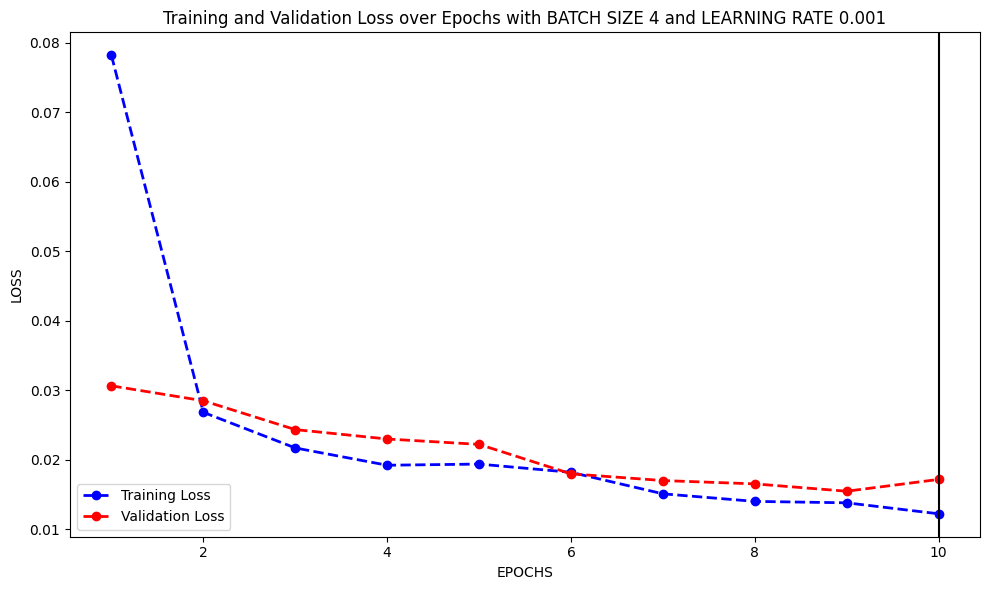

In [71]:
EPOCHS_RAN = range(1, BEST_HYPER_PARAMETERS['epochs_completed']+1)

# plotting loss curves over epochs
plt.figure(figsize=(10,6))
plt.plot(EPOCHS_RAN, BEST_HYPER_PARAMETERS['training_loss'], label="Training Loss",
         color='blue', marker='o', linestyle='dashed', linewidth=2)
plt.plot(EPOCHS_RAN, BEST_HYPER_PARAMETERS['validation_loss'], label="Validation Loss",
         color='red', marker='o', linestyle='dashed', linewidth=2)
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')
plt.axvline(x=BEST_HYPER_PARAMETERS['epochs_completed'], color='black', linestyle='-')
plt.title(f'Training and Validation Loss over Epochs with BATCH SIZE {BEST_BATCH_SIZE} and LEARNING RATE {BEST_LR}')
plt.legend()
plt.tight_layout()
plt.show()

Loading the final model

In [72]:
FINAL_MODEL = torch.hub.load("intel-isl/MiDaS", MODEL_TYPE)
FINAL_MODEL.load_state_dict(torch.load(f"/content/drive/MyDrive/midas_bs{BEST_BATCH_SIZE}_lr{BEST_LR}.pth"))

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


<All keys matched successfully>

Final Prediction and Test Set Evaluation

In [73]:
# setting to evaluation mode
FINAL_MODEL.to(device)
FINAL_MODEL.eval()

# set up data loader
Test_loader = DataLoader(Test_dataset, batch_size = BEST_BATCH_SIZE, shuffle=False)

# testing
test_loss = 0.
with torch.no_grad():
  for i, batch in enumerate(Test_loader):
    test_color_image_tensor = batch['color'].to(device)
    test_depth_image_tensor = batch['depth_gt'].to(device)

    # final predictions
    final_predictions = MIDAS_HYBRID_MODEL(test_color_image_tensor)
    test_loss += scale_invariant_loss(final_predictions, test_depth_image_tensor).item()

    # get images for 1 batch
    if i == 0:
      visualization_batch = {
          'color': test_color_image_tensor.cpu(),
          'depth_gt': test_depth_image_tensor.cpu(),
          'model_depth_map': final_predictions.cpu()
      }

average_test_loss = test_loss / len(Test_loader)
print("Average Test loss: {}".format(round(average_test_loss, 4)))

Average Test loss: 0.0221


Visualize the first batch of predictions vs ground truth

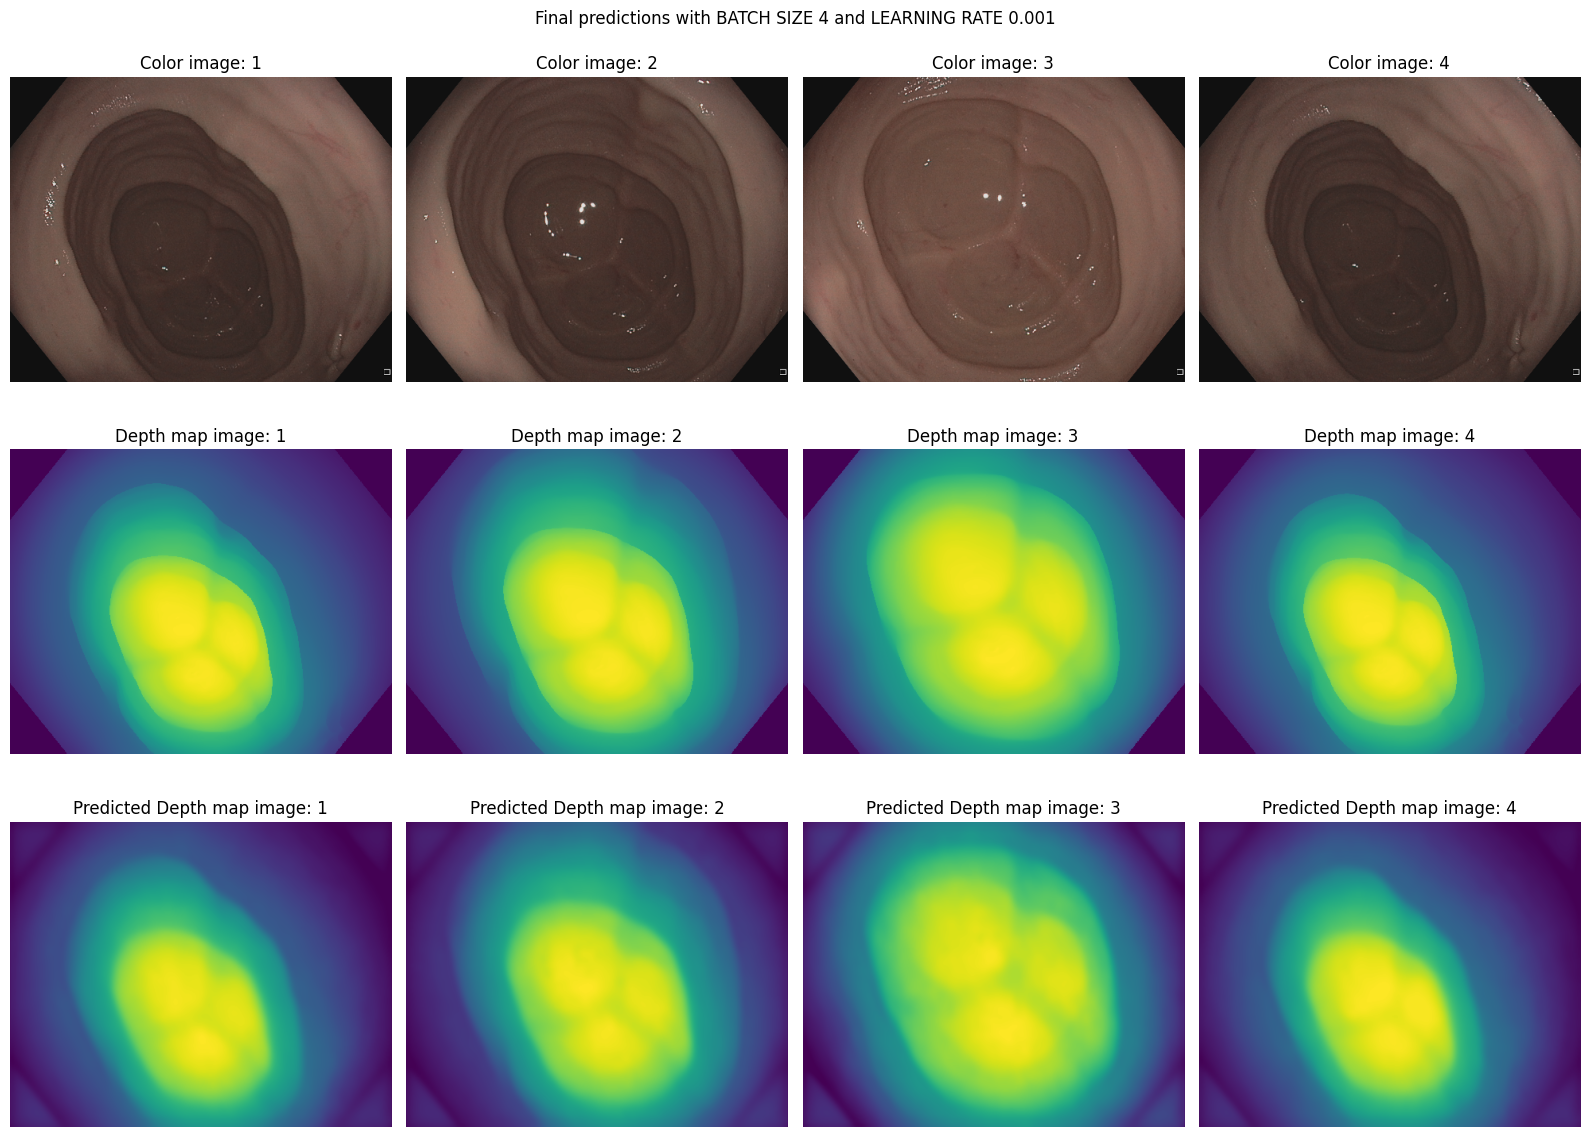

In [74]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize =(16,12))

for i in range(4):
  depth_img = visualization_batch['depth_gt'][i]
  depth_pred = visualization_batch['model_depth_map'][i].numpy()
  color_img = visualization_batch['color'][i].permute(1,2,0).numpy()
  color_img = (color_img - color_img.min()) / (color_img.max() - color_img.min())

  # color image
  axes[0, i].imshow(color_img)
  axes[0, i].set_title('Color image: {}'.format(i+1))
  axes[0, i].axis('off')

  # depth image
  axes[1, i].imshow(depth_img)
  axes[1, i].set_title('Depth map image: {}'.format(i+1))
  axes[1, i].axis('off')

  # predicted depth map
  axes[2, i].imshow(depth_pred)
  axes[2, i].set_title('Predicted Depth map image: {}'.format(i+1))
  axes[2, i].axis('off')

plt.suptitle(f'Final predictions with BATCH SIZE {BEST_BATCH_SIZE} and LEARNING RATE {BEST_LR}')
plt.tight_layout()
plt.show()

Comparing fine tuned model predictions with base model predictions

In [ ]:
BASE_MODEL = torch.hub.load("intel-isl/MiDaS", MODEL_TYPE)
for param in BASE_MODEL.parameters():
  param.requires_grad = False

BASE_MODEL.to(device)

In [78]:
base_model_test_loss = 0.

BASE_MODEL.eval()
with torch.no_grad():
  for i, batch in enumerate(Test_loader):
    color_images_base_tensor = batch['color'].to(device)
    depth_images_base_tensor = batch['depth_gt'].to(device)

    BASE_predictions = BASE_MODEL(color_images_base_tensor)
    base_model_test_loss += scale_invariant_loss(BASE_predictions, depth_images_base_tensor).item()

    if i == 0:
      BASE_visualization_batch = {
          'base_depth_pred': BASE_predictions.cpu()
      }

average_base_test_loss = base_model_test_loss / len(Test_loader)

# concatenating vizualization df
combined_visualization_batch = {
    'color': visualization_batch['color'],
    'depth_gt': visualization_batch['depth_gt'],
    'tuned_depth_pred': visualization_batch['model_depth_map'],
    'base_depth_pred': BASE_visualization_batch['base_depth_pred']
}

print(f"Base Model Evaluation on Test data: {round(average_base_test_loss, 4)}\n \
Model performance difference = Tuned model average loss - Base model average loss \n \
= {round((average_test_loss - base_model_test_loss),4)}")


Base Model Evaluation on Test data: 0.7228
 Model performance difference = Tuned model average loss - Base model average loss 
 = -7.9283


Output depth map for base model

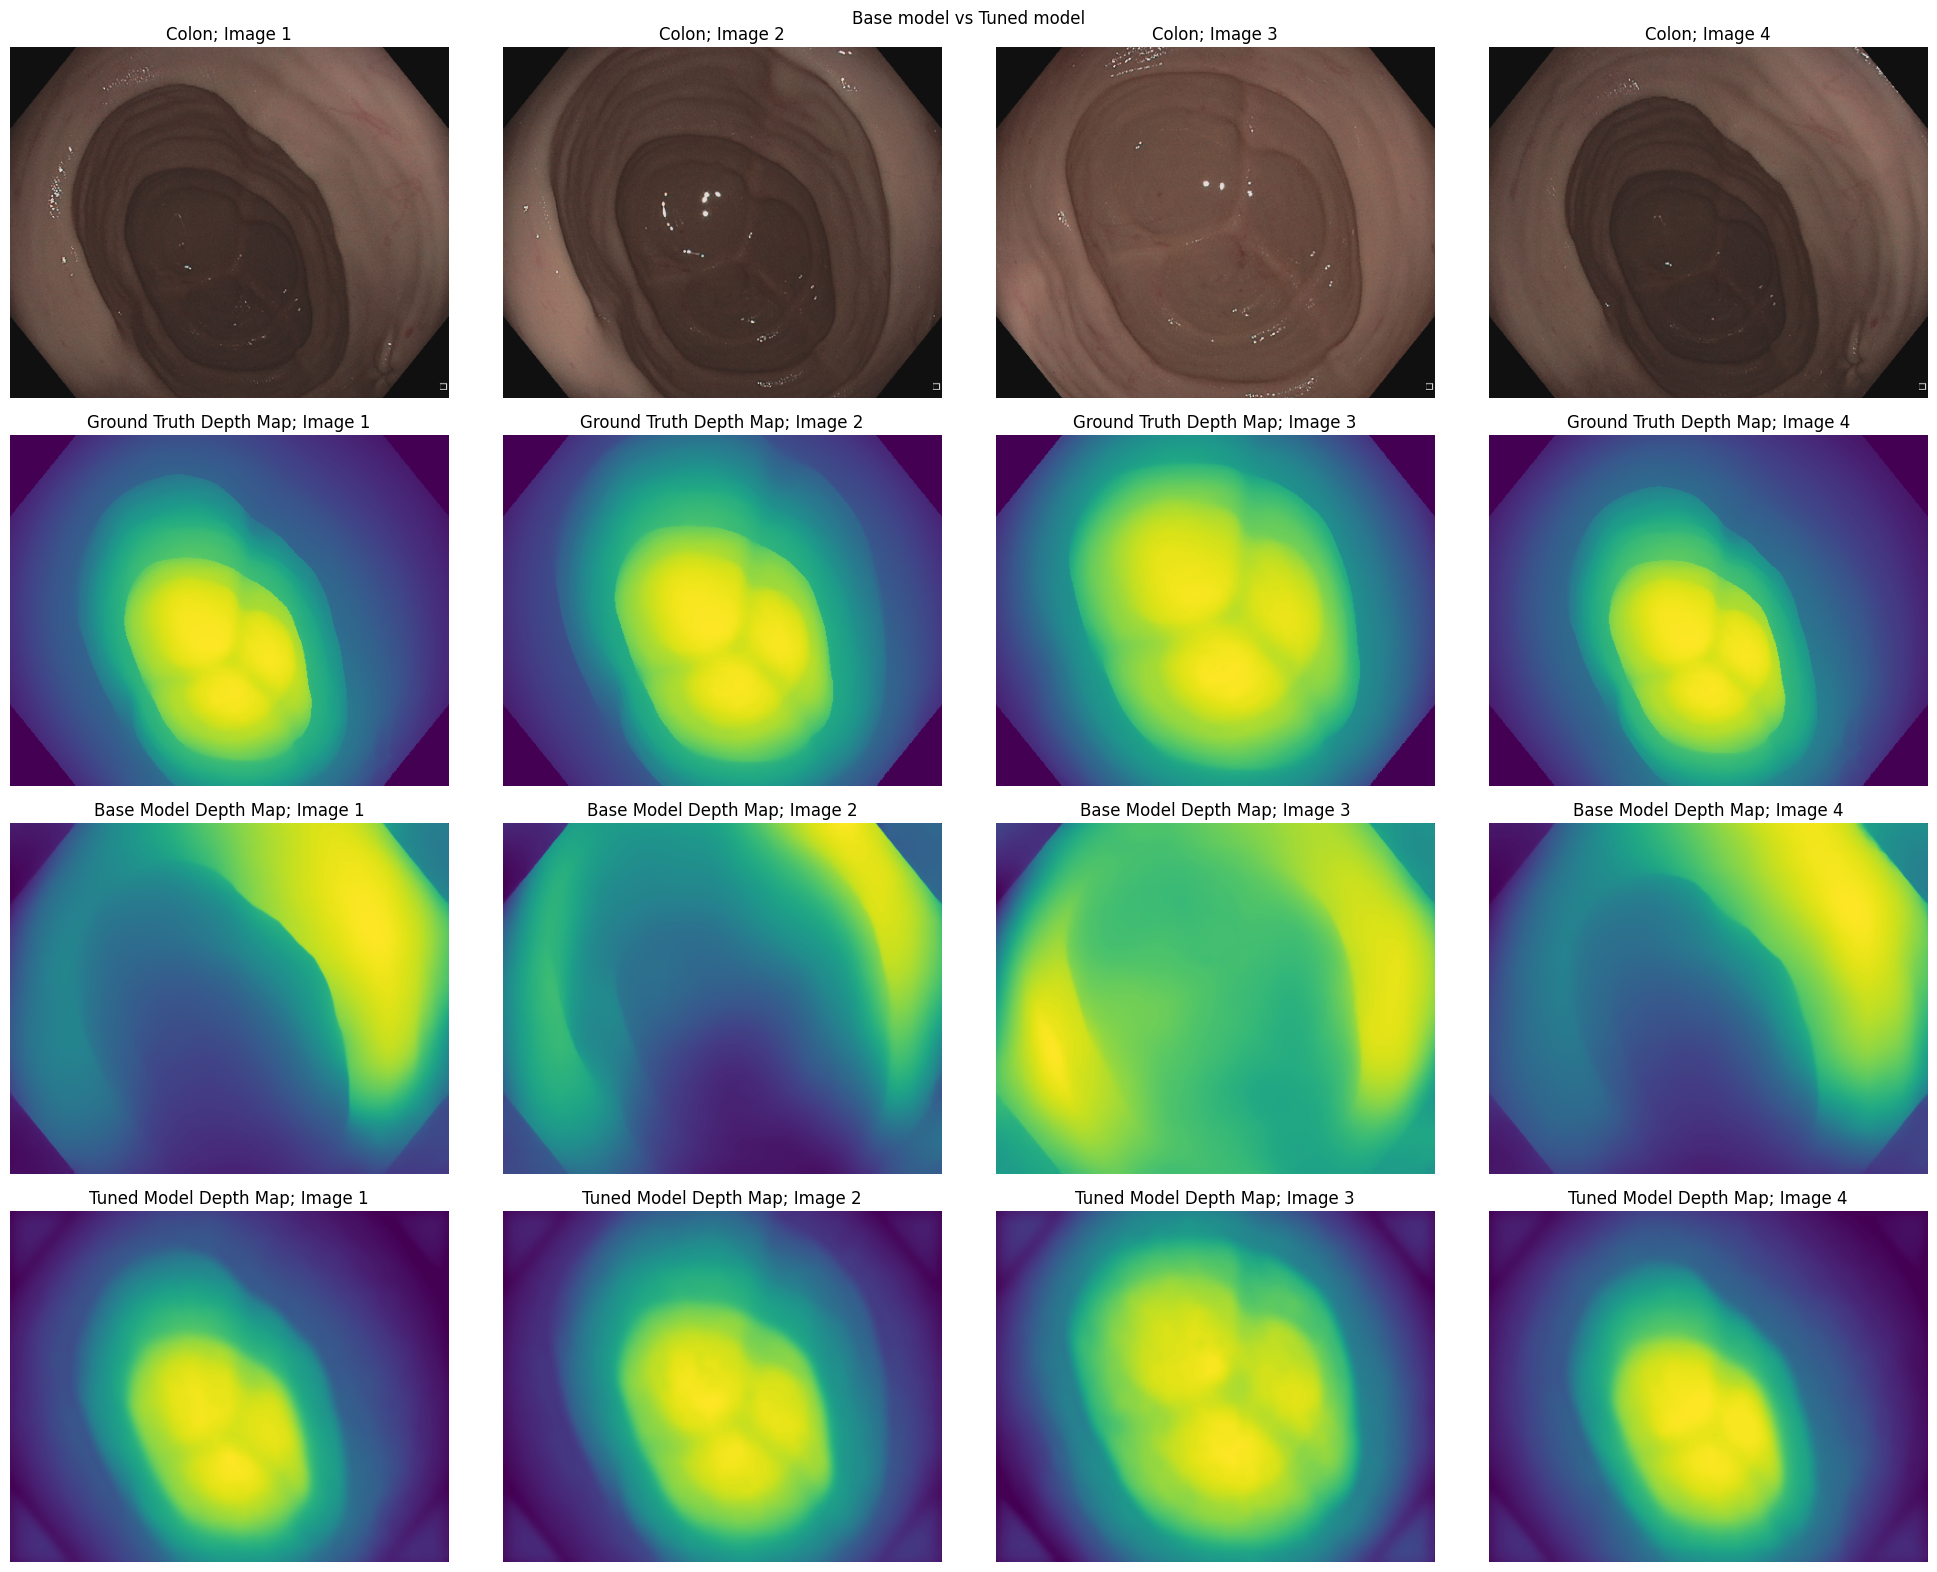

In [92]:
row_labels = ['Colon', 'Ground Truth Depth Map', 'Base Model Depth Map', 'Tuned Model Depth Map']
num_images = len(combined_visualization_batch)

# plot
fig, axes = plt.subplots(nrows=4, ncols=num_images, figsize=(20,16))
for i in range(num_images):
  color_img = combined_visualization_batch['color'][i].permute(1, 2, 0).numpy()
  color_img = (color_img - color_img.min()) / (color_img.max() - color_img.min())

  axes[0, i].imshow(color_img)
  axes[1, i].imshow(combined_visualization_batch['depth_gt'][i].numpy())
  axes[2, i].imshow(combined_visualization_batch['base_depth_pred'][i].numpy())
  axes[3, i].imshow(combined_visualization_batch['tuned_depth_pred'][i].numpy())

  for row in range(4):
    axes[row, i].axis("off")

for row, label in enumerate(row_labels):
  axes[row, 0].set_title(f"{label}; Image 1")
  axes[row, 1].set_title(f"{label}; Image 2")
  axes[row, 2].set_title(f"{label}; Image 3")
  axes[row, 3].set_title(f"{label}; Image 4")

plt.suptitle("Base model vs Tuned model", fontsize=12)
plt.subplots_adjust(left=0.1)
plt.tight_layout()
plt.show()